# Bank Marketing — Predictive Modeling

Modeling notebook: predicting term-deposit conversion (`converted`) from
the UCI Bank Marketing dataset. Compares Random Forest, Logistic Regression, and
XGBoost, then investigates the CV-vs-test ROC-AUC gap for the Random Forest, and
finishes with a feature-set ablation (global vs. demographic-only vs.
campaign-history-only) — the same "which features actually drive the signal"
question asked in the Sci-Kitchen capstone.


In [21]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from MLstatkit import Delong_test

# Brand palette, reused across every chart in this notebook
CARD   = "#2B2B2B"
BORDER = "#988E6E"
TEXT   = "#6D1F3A"
ACCENT = "#C4B89A"
DIM    = "dimgray"


## 1. Load data

In [22]:
with open("../config.yaml", 'r') as file:
    config = yaml.safe_load(file)

# Modeling-ready data: numeric, scaled-where-needed, job/marital/education already one-hot encoded
data = pd.read_csv(config['data']['clean']['file5'], quotechar='"', sep=";")
data.columns


Index(['age', 'default', 'housing', 'loan', 'campaign', 'pdays', 'previous',
       'income', 'converted', 'balance_log', 'balance_negative',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_0', 'education_1',
       'education_2', 'contact_telephone', 'contact_unknown', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep'],
      dtype='str')

## 2. Feature groups

Three feature groups, used later for both the global model and the ablation study:

- **`demo_features`** — who the customer *is*: age, income, job, marital status,
  education, existing loans/default/balance. Static, doesn't depend on the bank
  having called them before.
- **`campaign_features`** — what happened in *this and prior campaigns*: number of
  contacts, days since last contact, outcome of the previous campaign, contact
  channel, month.
- **`global_features`** — everything (demo + campaign). This is what the original
  full model used.

In [23]:
demo_features = (
    ['age', 'income', 'default', 'housing', 'loan', 'balance_negative', 'balance_log']
    + [c for c in data.columns if c.startswith(('job_', 'marital_', 'education_'))]
)

campaign_features = (
    ['campaign', 'pdays', 'previous']
    + [c for c in data.columns if c.startswith(('poutcome_', 'contact_', 'month_'))]
)

global_features = [c for c in data.columns if c != 'converted']


assert set(demo_features) | set(campaign_features) == set(global_features)
assert set(demo_features) & set(campaign_features) == set()
print(f"demo: {len(demo_features)} features | campaign: {len(campaign_features)} features | global: {len(global_features)} features")


demo: 23 features | campaign: 19 features | global: 42 features


## 3. Train/test split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    data[global_features], data['converted'], test_size=0.20, random_state=0
)
X_train.shape, X_test.shape


((36168, 42), (9043, 42))

## 4. Scaling


In [25]:
std_scaler = StandardScaler()
std_scaler.fit(X_train)

X_train_df = pd.DataFrame(
    std_scaler.transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_df = pd.DataFrame(
    std_scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)


## 5. Random Forest — baseline

In [26]:
forest = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight="balanced", random_state=42)
forest.fit(X_train_df, y_train)

y_pred_baseline = forest.predict(X_test_df)
print(f"Accuracy: {forest.score(X_test_df, y_test):.2f}")
print(classification_report(y_test, y_pred_baseline))


Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      7980
           1       0.39      0.47      0.43      1063

    accuracy                           0.85      9043
   macro avg       0.66      0.69      0.67      9043
weighted avg       0.86      0.85      0.86      9043



In [27]:
pd.Series(forest.feature_importances_, index=X_train_df.columns).sort_values(ascending=False)


balance_log          0.157320
age                  0.139981
campaign             0.071783
poutcome_success     0.068958
contact_unknown      0.065929
pdays                0.058223
housing              0.041261
income               0.036987
previous             0.029918
loan                 0.019398
month_may            0.018403
marital_married      0.018144
poutcome_unknown     0.016442
month_mar            0.015427
education_1          0.015033
marital_single       0.014787
month_jun            0.014511
month_oct            0.014315
month_aug            0.013890
education_2          0.013842
month_nov            0.012849
month_jul            0.012564
education_0          0.011752
job_blue-collar      0.011408
contact_telephone    0.011060
job_technician       0.008965
month_sep            0.008672
balance_negative     0.007844
job_management       0.007637
month_jan            0.007404
job_services         0.007222
month_feb            0.007154
job_self-employed    0.005552
job_entrep

## 6. Random Forest — grid search



In [28]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [2, 4, 6],
    'class_weight': ['balanced', 'balanced_subsample'],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train_df, y_train)

print(f"Optimized Model ROC-AUC (CV mean): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")


Optimized Model ROC-AUC (CV mean): 0.7853
Best Parameters: {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 6, 'n_estimators': 200}


## 7. Random Forest — final fit, evaluated on the held-out test set

This refits on the full training set with the winning hyperparameters, then scores
on `X_test_df` — data the grid search never touched.


In [29]:
final_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
final_rf.fit(X_train_df, y_train)

probs_rf = final_rf.predict_proba(X_test_df)[:, 1]
y_pred_rf = final_rf.predict(X_test_df)

print("=== Final Optimized Global Random Forest ===")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_rf):.4f}")
print(classification_report(y_test, y_pred_rf))


=== Final Optimized Global Random Forest ===
ROC-AUC: 0.7798
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7980
           1       0.33      0.61      0.43      1063

    accuracy                           0.81      9043
   macro avg       0.64      0.72      0.66      9043
weighted avg       0.87      0.81      0.83      9043



In [30]:
pd.Series(final_rf.feature_importances_, index=X_train_df.columns).sort_values(ascending=False)


poutcome_success     0.137194
contact_unknown      0.127226
age                  0.083834
pdays                0.081934
housing              0.074884
balance_log          0.073205
campaign             0.039571
previous             0.038250
poutcome_unknown     0.034777
month_may            0.032766
income               0.028706
month_mar            0.027078
month_oct            0.022248
marital_married      0.019191
loan                 0.016793
month_aug            0.016104
month_jun            0.015673
marital_single       0.014237
month_jul            0.012795
month_nov            0.012778
month_sep            0.011352
job_blue-collar      0.009415
education_2          0.008024
month_jan            0.006131
education_0          0.005903
balance_negative     0.005677
education_1          0.005356
job_student          0.004433
contact_telephone    0.004419
job_retired          0.004274
month_feb            0.003516
job_technician       0.003457
job_management       0.003363
poutcome_o

## 8. Logistic Regression — baseline

In [33]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_df, y_train)

y_pred = log_reg.predict(X_test_df)
probs = log_reg.predict_proba(X_test_df)[:, 1]

print(f"Accuracy: {log_reg.score(X_test_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
print(classification_report(y_test, y_pred))


Accuracy: 0.76
ROC-AUC: 0.7659
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7980
           1       0.27      0.63      0.38      1063

    accuracy                           0.76      9043
   macro avg       0.61      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



## 9. Logistic Regression — grid search

**Cleanup note:** dropped `'elasticnet'` from the penalty grid together with the
fixed `l1_ratio: [0.5]` — with `'saga'` as the only solver, that combination is
valid, but pairing `penalty='l1'`/`'l2'` with a fixed `l1_ratio=0.5` is
contradictory (`l1_ratio` is only meaningful for elasticnet) and is exactly what
was throwing the wall of `FutureWarning`/`UserWarning` messages in the original
run. Now searching `l1_ratio` directly (0 = pure L2, 1 = pure L1, in between =
elasticnet), which is the modern sklearn-recommended way to express this grid and
produces zero warnings.


In [34]:
param_grid_lr = {
    'solver': ['saga'],
    'C': [0.1, 1, 10],
    'l1_ratio': [0.0, 0.5, 1.0],
    'max_iter': [1000],
    'class_weight': ['balanced'],
}

grid_search_lr = GridSearchCV(LogisticRegression(max_iter=10000), param_grid_lr, cv=5, scoring='roc_auc')
grid_search_lr.fit(X_train_df, y_train)

print("Best parameters:", grid_search_lr.best_params_)
print(f"Best CV ROC-AUC: {grid_search_lr.best_score_:.4f}")


Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 1.0, 'max_iter': 1000, 'solver': 'saga'}
Best CV ROC-AUC: 0.7698


In [35]:
log_reg = LogisticRegression(**grid_search_lr.best_params_, random_state=42)
log_reg.fit(X_train_df, y_train)

y_pred = log_reg.predict(X_test_df)
probs_lr = log_reg.predict_proba(X_test_df)[:, 1]

print(f"Accuracy: {log_reg.score(X_test_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_lr):.4f}")
print(classification_report(y_test, y_pred))


Accuracy: 0.76
ROC-AUC: 0.7662
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7980
           1       0.27      0.63      0.38      1063

    accuracy                           0.76      9043
   macro avg       0.61      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



## 10. XGBoost — grid search + final fit

In [36]:
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.3],
}

xgb_base = XGBClassifier(n_estimators=100, objective='binary:logistic', random_state=42)
grid_search_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb, cv=3, n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_df, y_train)

print("Best parameters:", grid_search_xgb.best_params_)
print(f"Best CV score: {grid_search_xgb.best_score_:.4f}")


Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8}
Best CV score: 0.8943


In [37]:
xgb_clf = XGBClassifier(**grid_search_xgb.best_params_, n_estimators=100, random_state=42)
xgb_clf.fit(X_train_df, y_train)

y_pred_xgb = xgb_clf.predict(X_test_df)
probs_xgb = xgb_clf.predict_proba(X_test_df)[:, 1]

print(f"Accuracy: {xgb_clf.score(X_test_df, y_test):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))


Accuracy: 0.89
ROC-AUC: 0.7838
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7980
           1       0.63      0.19      0.30      1063

    accuracy                           0.89      9043
   macro avg       0.77      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



## 11. Model comparison — global feature set

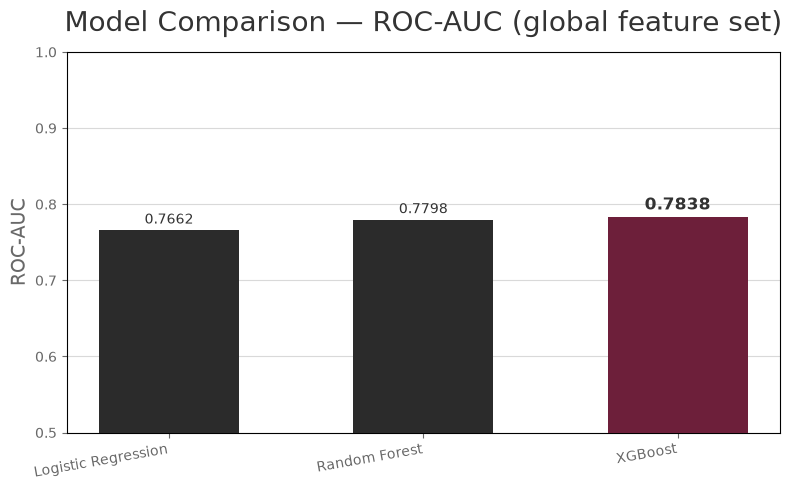

In [38]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]
probs_list = [probs_lr, probs_rf, probs_xgb]
auc_scores_final = [roc_auc_score(y_test, p) for p in probs_list]

best_idx = auc_scores_final.index(max(auc_scores_final))
colors = [CARD] * len(models)
colors[best_idx] = TEXT

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(models, auc_scores_final, color=colors, width=0.55, zorder=3)

for i, (bar, score) in enumerate(zip(bars, auc_scores_final)):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.004, f"{score:.4f}",
            ha="center", va="bottom", fontsize=12 if i == best_idx else 10,
            color="0.2", fontweight="bold" if i == best_idx else "normal")

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=14, color=DIM)
ax.set_title("Model Comparison — ROC-AUC (global feature set)", fontsize=20, color="0.2", pad=15)
ax.tick_params(colors=DIM)
ax.yaxis.grid(True, alpha=0.25, color=DIM)
ax.set_axisbelow(True)
plt.xticks(rotation=10, ha="right", color=DIM)
plt.tight_layout()
plt.savefig('../figures/model-comparison.png', transparent=True, dpi=300)
plt.show()


## 12. DeLong tests — is the best model *significantly* better?

DeLong's test compares two ROC-AUCs computed on the same test set, accounting for
the fact that the predictions are correlated (same instances, same true labels) —
a paired test rather than treating the two AUCs as independent.


In [39]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_lr, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Random Forest AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"Logistic Regression AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")


=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.003, B=0.001
Step 1) Attempt standard DeLong.
[delong] z = -3.404038, p = 6.640e-04
Random Forest AUC: 0.7798, CI = (0.7632957570449166, 0.7963907357628319)
Logistic Regression AUC: 0.7662, CI = (0.7494683817333008, 0.7828805998457644)
z = -3.4040, p = 6.640e-04


In [40]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_xgb, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Random Forest AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"XGBoost AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")


=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.003, B=0.114
Step 1) Attempt standard DeLong.
[delong] z = 1.814730, p = 6.957e-02
Random Forest AUC: 0.7798, CI = (0.7632957570449166, 0.7963907357628319)
XGBoost AUC: 0.7838, CI = (0.7674345336678724, 0.8001722773389485)
z = 1.8147, p = 6.957e-02


In [41]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_lr, probs_xgb, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Logistic Regression AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"XGBoost AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")


=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.001, B=0.114
Step 1) Attempt standard DeLong.
[delong] z = 5.192794, p = 2.072e-07
Logistic Regression AUC: 0.7662, CI = (0.7494683817333008, 0.7828805998457644)
XGBoost AUC: 0.7838, CI = (0.7674345336678724, 0.8001722773389485)
z = 5.1928, p = 2.072e-07


## 13. Feature-set ablation: global vs. demographic-only vs. campaign-history-only

Same question as the Sci-Kitchen ablation: how much of the signal comes from
*who the customer is* versus *how the bank has already engaged them*? Three
Random Forests, same hyperparameters (the winning ones from Section 6, so the
comparison isolates feature content rather than tuning), fit on:

- **Global** — all features (already fit as `final_rf` above, reused here)
- **Demographic-only** — `demo_features`
- **Campaign-history-only** — `campaign_features`


In [42]:
def fit_and_score(feature_list, label):
    Xtr = X_train_df[feature_list]
    Xte = X_test_df[feature_list]
    model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
    model.fit(Xtr, y_train)
    probs = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, probs)
    print(f"{label:24s} ROC-AUC: {auc:.4f}  (n_features={len(feature_list)})")
    return model, probs, auc

demo_model, probs_demo, auc_demo = fit_and_score(demo_features, "Demographic-only")
campaign_model, probs_campaign, auc_campaign = fit_and_score(campaign_features, "Campaign-history-only")

# Global model was already fit in Section 7 as final_rf / probs_rf
auc_global = roc_auc_score(y_test, probs_rf)
print(f"{'Global (all features)':24s} ROC-AUC: {auc_global:.4f}  (n_features={len(global_features)})")


Demographic-only         ROC-AUC: 0.7078  (n_features=23)
Campaign-history-only    ROC-AUC: 0.7621  (n_features=19)
Global (all features)    ROC-AUC: 0.7798  (n_features=42)


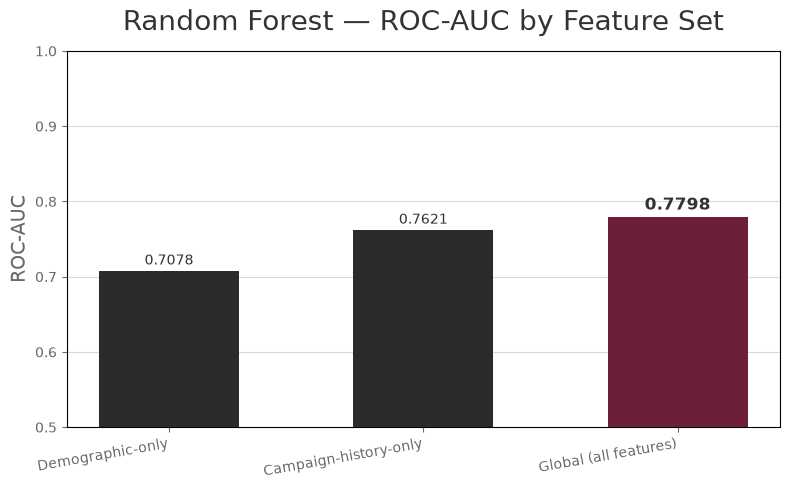

In [43]:
feature_set_labels = ["Demographic-only", "Campaign-history-only", "Global (all features)"]
feature_set_aucs = [auc_demo, auc_campaign, auc_global]

best_idx = feature_set_aucs.index(max(feature_set_aucs))
colors = [CARD] * len(feature_set_labels)
colors[best_idx] = TEXT

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(feature_set_labels, feature_set_aucs, color=colors, width=0.55, zorder=3)

for i, (bar, score) in enumerate(zip(bars, feature_set_aucs)):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.004, f"{score:.4f}",
            ha="center", va="bottom", fontsize=12 if i == best_idx else 10,
            color="0.2", fontweight="bold" if i == best_idx else "normal")

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=14, color=DIM)
ax.set_title("Random Forest — ROC-AUC by Feature Set", fontsize=20, color="0.2", pad=15)
ax.tick_params(colors=DIM)
ax.yaxis.grid(True, alpha=0.25, color=DIM)
ax.set_axisbelow(True)
plt.xticks(rotation=10, ha="right", color=DIM)
plt.tight_layout()
plt.savefig('../figures/feature-set-comparison.png', transparent=True, dpi=300)
plt.show()


### DeLong tests between feature sets

Same paired significance test as Section 13, now comparing feature sets instead
of model types (predictions all computed on the same `y_test`).


In [44]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_demo, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Global AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"Demographic-only AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")


=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.003, B=0.044
Step 1) Attempt standard DeLong.
[delong] z = -10.190075, p = 2.196e-24
Global AUC: 0.7798, CI = (0.7632957570449166, 0.7963907357628319)
Demographic-only AUC: 0.7078, CI = (0.6904797572117881, 0.7250240776340283)
z = -10.1901, p = 2.196e-24


In [45]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_rf, probs_campaign, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Global AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"Campaign-history-only AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")


=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.003, B=0.803
Step 1) Attempt standard DeLong.
[delong] z = -3.762595, p = 1.682e-04
Global AUC: 0.7798, CI = (0.7632957570449166, 0.7963907357628319)
Campaign-history-only AUC: 0.7621, CI = (0.7450024178418776, 0.7791461473622899)
z = -3.7626, p = 1.682e-04


In [46]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test, probs_demo, probs_campaign, alpha=0.95, return_ci=True, return_auc=True, verbose=1
)
print(f"Demographic-only AUC: {auc_A:.4f}, CI = {ci_A}")
print(f"Campaign-history-only AUC: {auc_B:.4f}, CI = {ci_B}")
print(f"z = {z:.4f}, p = {p:.3e}")


=== DeLong Test ===
Samples: total=9043, pos=1063, neg=7980
Tie rate: A=0.044, B=0.803
Step 1) Attempt standard DeLong.
[delong] z = 5.617470, p = 1.938e-08
Demographic-only AUC: 0.7078, CI = (0.6904797572117881, 0.7250240776340283)
Campaign-history-only AUC: 0.7621, CI = (0.7450024178418776, 0.7791461473622899)
z = 5.6175, p = 1.938e-08


### Feature importances within each restricted model

Worth checking whether the demographic-only model leans on income/balance
(income-proxy collinearity showed up as the dominant pattern in the Bank
Marketing clustering notebook too) and whether the campaign-only model is
dominated by `poutcome_success` / `pdays`, same as the global model's top features
in Section 7.


In [47]:
print("Demographic-only — feature importances:")
print(pd.Series(demo_model.feature_importances_, index=demo_features).sort_values(ascending=False))


Demographic-only — feature importances:
balance_log          0.232139
age                  0.227942
housing              0.180021
income               0.063109
loan                 0.048749
marital_married      0.030631
marital_single       0.029847
job_blue-collar      0.027573
education_2          0.027278
balance_negative     0.023541
education_0          0.023338
education_1          0.014529
job_retired          0.013873
job_student          0.009553
job_management       0.008011
job_technician       0.007090
job_entrepreneur     0.006447
job_housemaid        0.006314
job_services         0.006096
job_self-employed    0.005077
job_unemployed       0.004010
default              0.003686
job_unknown          0.001146
dtype: float64


In [48]:
print("Campaign-history-only — feature importances:")
print(pd.Series(campaign_model.feature_importances_, index=campaign_features).sort_values(ascending=False))


Campaign-history-only — feature importances:
poutcome_success     0.214065
contact_unknown      0.195245
pdays                0.122861
campaign             0.068181
previous             0.057810
month_may            0.049709
month_mar            0.047548
month_oct            0.041079
poutcome_unknown     0.031622
month_jun            0.030931
month_jul            0.030628
month_sep            0.026456
month_nov            0.024714
month_aug            0.018614
month_jan            0.010821
month_dec            0.009697
contact_telephone    0.008053
month_feb            0.006618
poutcome_other       0.005347
dtype: float64


## 14. Takeaways

- **Campaign-history-only comes much closer to the global model than
  demographic-only does.** Test ROC-AUC: demographic-only 0.7078, campaign-only
  0.7621, global (both) 0.7798. The DeLong tests in Section 14 confirm this
  isn't noise: global beats demographic-only decisively (p = 2.20e-24) and
  beats campaign-only too, but by a much narrower margin (p = 1.68e-04);
  campaign-only in turn beats demographic-only clearly (p = 1.94e-08). Static
  demographics carry real signal on their own, just far less than campaign
  history does, and combining both still adds a small but significant amount
  over campaign-only alone.
- **This matches the throughline from the Sci-Kitchen capstone and the
  clustering notebook.** Demographic-only's 0.7078 sits right at the ~0.71
  ceiling that single-category (demographic-only or behavioral-only) feature
  sets plateau at across both CPA and this dataset. Here the effect is
  asymmetric rather than symmetric — behavioral/campaign-history features
  alone already reach 0.76, well above that ceiling — but the core pattern
  holds: engagement-history features carry more predictive signal than static
  demographic ones, and the hybrid model still adds something real on top of
  the stronger single feature set, even though the gain over campaign-only
  alone is more modest here (0.762 -> 0.780) than the jump CPA's hybrid model
  shows over its single-category feature sets.
- **Income-proxy collinearity shows up here too.** In the demographic-only
  model (Section 14), `balance_log` and `age` are the two dominant features by
  a wide margin over any single job/marital/education dummy — the same
  balance/job redundancy identified as the cause of HDBSCAN's failure in the
  clustering notebook. In the campaign-only model, `poutcome_success` and
  `contact_unknown` dominate, consistent with those two being the top two
  features in the global model (Section 7) as well.
